# Mr Beast Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('mrbeast_dataset/MrBeast_youtube_stats.csv')

In [3]:
df.groupby('id')['title'].nunique().sort_values(ascending=False) #.head(50)

id
0CTp1a-aCUM    5
2isYuQZMbdU    4
65fN_OUawjk    4
48h57PspBec    3
iogcY_4xGjo    3
              ..
MLN6TRB9Jxw    1
MOGW3v3pJ5Y    1
MUQCwdkEbq0    1
MZatl6kUZpw    1
zxuICI0kL3s    1
Name: title, Length: 914, dtype: int64

In [4]:
df['pull_date'] = pd.to_datetime(df['pull_date'])

<Axes: title={'center': 'Number of Videos pulled per day'}, xlabel='pull_date'>

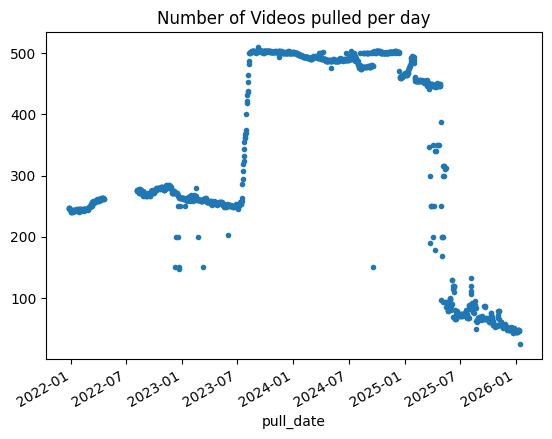

In [5]:
df['pull_date'].value_counts().sort_index().plot(style='.',
                                                title='Number of Videos pulled per day')

In [10]:
df = df.dropna(subset='viewCount').reset_index(drop=True)
df['viewCount'] = df['viewCount'].astype('int')

In [11]:
df.groupby(['id','title'])[['viewCount','pull_date']] \
        .max() \
        .reset_index() \
        .sort_values('viewCount')

,id,title,viewCount,pull_date
462,TGKkMl17Htg,"Battle Pirates, Unstoppable Ship!",35956,2023-08-07 00:09:55.117235+00:00
980,ywZy_Fo2ydo,Modern Art Is A Joke,36613,2023-08-27 00:12:06.324381+00:00
902,u6t4jrhs56Q,Top Youtube &quot;ShoutOuts&quot;,36633,2023-08-27 00:12:06.324381+00:00
110,6T17licWsQ4,Leaving For 7 Days,39197,2023-07-24 00:13:41.788641+00:00
255,GfgcVOuHLAo,Every FaZe Video Ever #karnageRC,39782,2023-10-24 00:10:57.951335+00:00
...,...,...,...,...
22,0e3GPea1Tyg,"$456,000 Squid Game In Real Life!",876009287,2025-09-22 00:05:48.981785+00:00
326,L5kIXRdwGAI,Katana Vs Bullet,1085305868,2025-10-18 00:02:51.349756+00:00
278,IQxea9UB1nQ,"$100,000,000 Car Doors",1186290758,2025-08-18 00:04:33.009006+00:00
550,YlvcFJOE-OE,Giving iPhones Instead Of Candy on Halloween,1585806289,2025-11-16 00:05:42.110033+00:00


<Axes: xlabel='pull_date'>

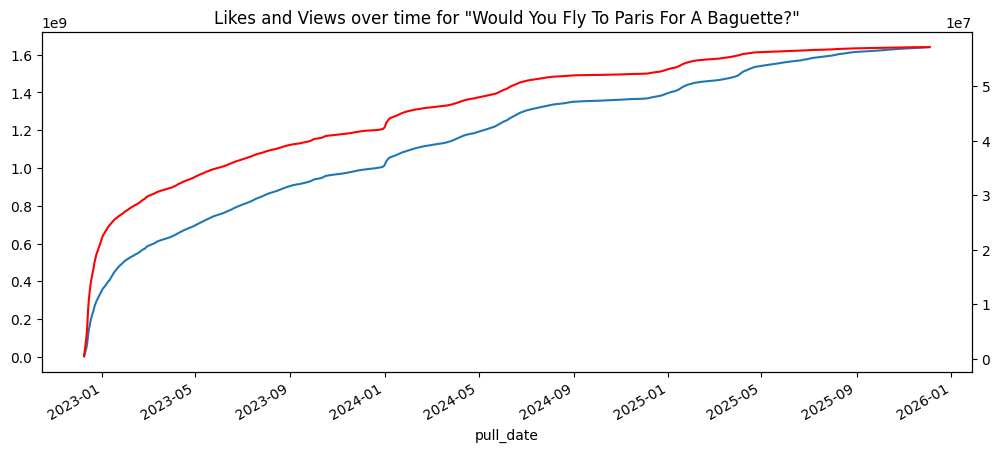

In [12]:
video_name = df.query('id == "se50viFJ0AQ"')['title'].values[0]
fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
df.query('id == "se50viFJ0AQ"').set_index('pull_date')['viewCount'].plot(
    ax=ax,
    title=f'Likes and Views over time for "{video_name}"')
df.query('id == "se50viFJ0AQ"').set_index('pull_date')['likeCount'].plot(ax=ax2, color='red')

# Read in our processed dataset

In [14]:
df = pd.read_parquet('mrbeast_dataset/MrBeast_youtube_stats_processed.parquet')

In [28]:
df['like_to_view_ratio'] = df['like_diff'] / df['view_diff']

In [29]:
df.query('view_diff != 0') \
        .sort_values('like_to_view_ratio', ascending=False)

,id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.url,...,localizations.en.title,localizations.en.description,snippet.tags,pull_date,time_since_last_pull,view_diff,like_diff,comment_diff,like_of_view_ratio,like_to_view_ratio
188205,uotb9ZHnI2g,"Tipping Pizza Delivery Guys $10,000",Download Quidd - http://bit.ly/2x2KvwR Please ...,2017-08-23 21:44:24+00:00,youtube#video,769,22178690,695773,40855,https://i.ytimg.com/vi/uotb9ZHnI2g/default.jpg,...,None,None,"['tipping pizza guys', 'tipping']",2024-05-08 00:10:49.880176+00:00,1 days 00:00:34.141142,309.0,695773.0,40855.0,2251.692557,2251.692557
188227,93s1JECSy60,"Giving My Mom $100,000 (Proudest Day Of My Life)",She started crying Download Quidd Here - http:...,2017-12-02 21:10:08+00:00,youtube#video,745,31480697,1529468,44545,https://i.ytimg.com/vi/93s1JECSy60/default.jpg,...,None,None,"['Giving mom 100000', 'giving my mom', 'mom']",2024-05-08 00:10:49.880176+00:00,1 days 00:00:34.141142,1021.0,1529468.0,44545.0,1498.009794,1498.009794
122591,_uwNDiU04zE,"I Donated $300,000 To People In Need",Subscribe and I'll Donate $0.10 To Charity New...,2021-02-13 21:00:01+00:00,youtube#video,654,55790801,3032540,146200,https://i.ytimg.com/vi/_uwNDiU04zE/default.jpg,...,"I Donated $300,000 To People In Need",Subscribe and I'll Donate $0.10 To Charity\n\n...,None,2024-09-21 00:07:46.820812+00:00,2 days 00:04:46.558049,-1.0,-167.0,-44.0,167.000000,167.000000
145082,_uwNDiU04zE,"I Donated $300,000 To People In Need",Subscribe and I'll Donate $0.10 To Charity New...,2021-02-13 21:00:01+00:00,youtube#video,654,55789183,3037291,149570,https://i.ytimg.com/vi/_uwNDiU04zE/default.jpg,...,"I Donated $300,000 To People In Need",Subscribe and I'll Donate $0.10 To Charity\n\n...,None,2024-08-05 00:06:32.183949+00:00,0 days 23:56:07.619352,-1.0,-164.0,-70.0,164.000000,164.000000
131792,_uwNDiU04zE,"I Donated $300,000 To People In Need",Subscribe and I'll Donate $0.10 To Charity New...,2021-02-13 21:00:01+00:00,youtube#video,654,55790913,3034367,147405,https://i.ytimg.com/vi/_uwNDiU04zE/default.jpg,...,"I Donated $300,000 To People In Need",Subscribe and I'll Donate $0.10 To Charity\n\n...,None,2024-09-01 00:06:15.728579+00:00,0 days 23:56:12.239023,-5.0,-393.0,-8.0,78.600000,78.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432860,zsADECFHY8w,4k Subscriber&#39;s! First Channel Story!,"To celebrate 4000 subscribers, I decided I wou...",2015-07-30 01:56:38+00:00,youtube#video,314,52585,1979,347,https://i.ytimg.com/vi/zsADECFHY8w/default.jpg,...,None,None,"['Mr.Beast', 'mr', 'beast', 'thanks', 'for', '...",2022-03-11 02:12:02.295306+00:00,NaT,NaN,NaN,NaN,NaN,NaN
82174,zvBXpoBegwE,I Got T-Series To Subscribe To Me,None,2024-12-09 17:00:01+00:00,youtube#video,31,2756050,298315,1889,https://i.ytimg.com/vi/zvBXpoBegwE/default.jpg,...,I Got T-Series To Subscribe To Me,None,None,2024-12-10 00:04:34.161738+00:00,NaT,NaN,NaN,NaN,NaN,NaN
415646,zv_oq5UNDAo,"How To SAT, Get Into Yale",These test taking skills will give you a score...,2015-04-13 11:08:02+00:00,youtube#video,245,26673,593,120,https://i.ytimg.com/vi/zv_oq5UNDAo/default.jpg,...,None,None,"['How', 'much', 'money', 'does', 'make', 'blac...",2022-08-29 00:30:32.501034+00:00,NaT,NaN,NaN,NaN,NaN,NaN
451033,zxYjTTXc-J8,"Last To Leave Circle Wins $500,000",THIS WAS THE CRAZIEST THING IVE EVER DONE! Get...,2021-08-31 20:01:03+00:00,youtube#video,1166,96827291,3497171,95177,https://i.ytimg.com/vi/zxYjTTXc-J8/default.jpg,...,None,None,None,2021-12-24 01:41:03.667334+00:00,NaT,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='pull_date'>

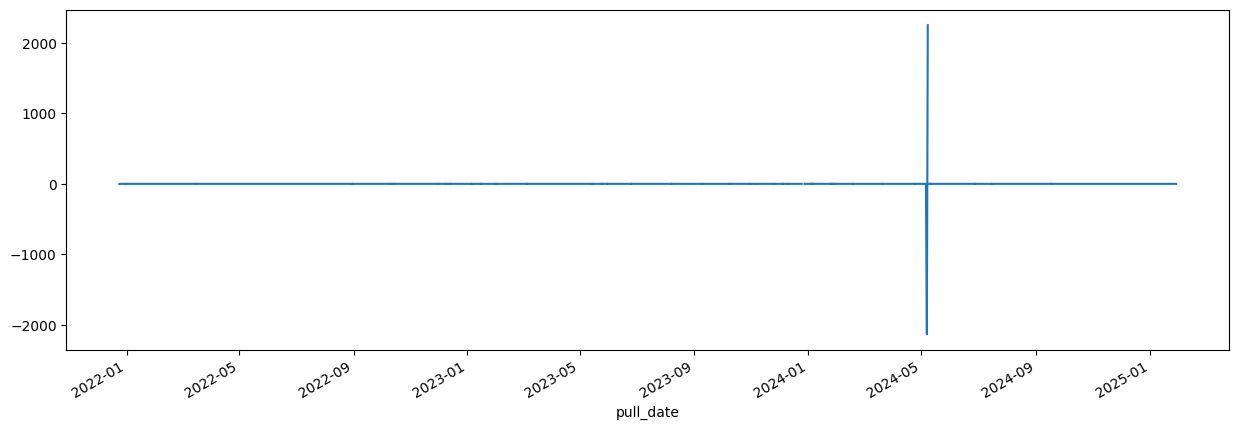

In [34]:
df.query('id == "uotb9ZHnI2g"').set_index('pull_date')['like_to_view_ratio'].plot(figsize=(15, 5))

451212             NaN
450965      773.529870
450724      552.000618
450472      823.959913
450224    14082.885432
              ...     
9169      86454.740390
9035      86488.827931
8923      86493.401954
8816      86278.808018
8725      86496.322920
Name: time_since_last_pull, Length: 447498, dtype: float64

In [59]:
df['view_diff_norm'] = df['view_diff'] / (df['time_since_last_pull'].dt.total_seconds() / (60 * 60 * 12))
df['like_diff_norm'] = df['like_diff'] / (df['time_since_last_pull'].dt.total_seconds() / (60 * 60 * 12))

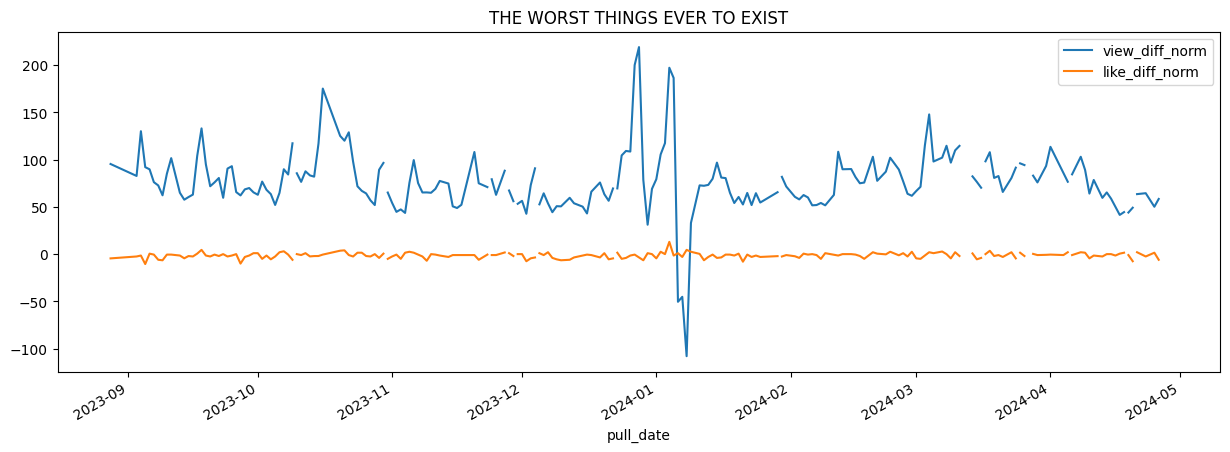

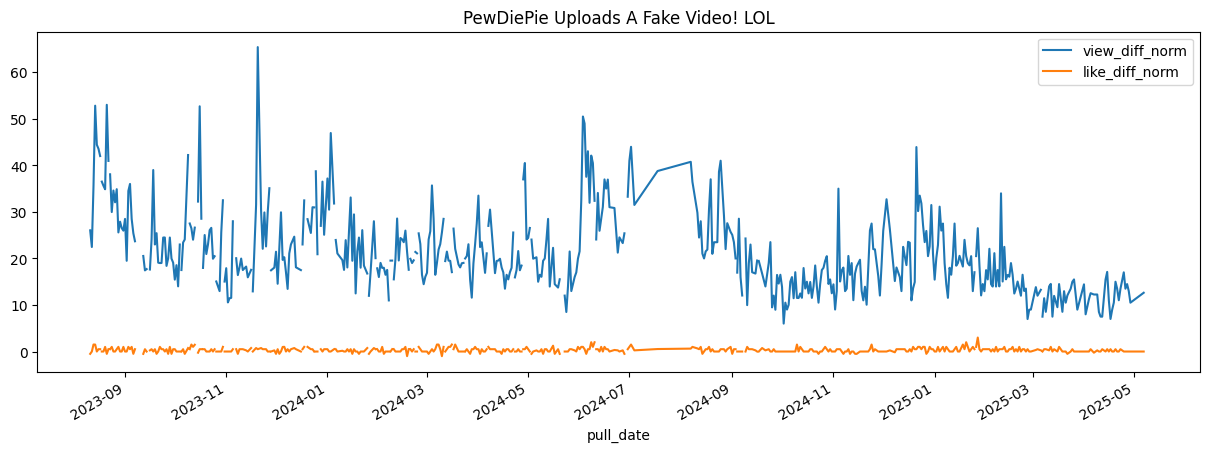

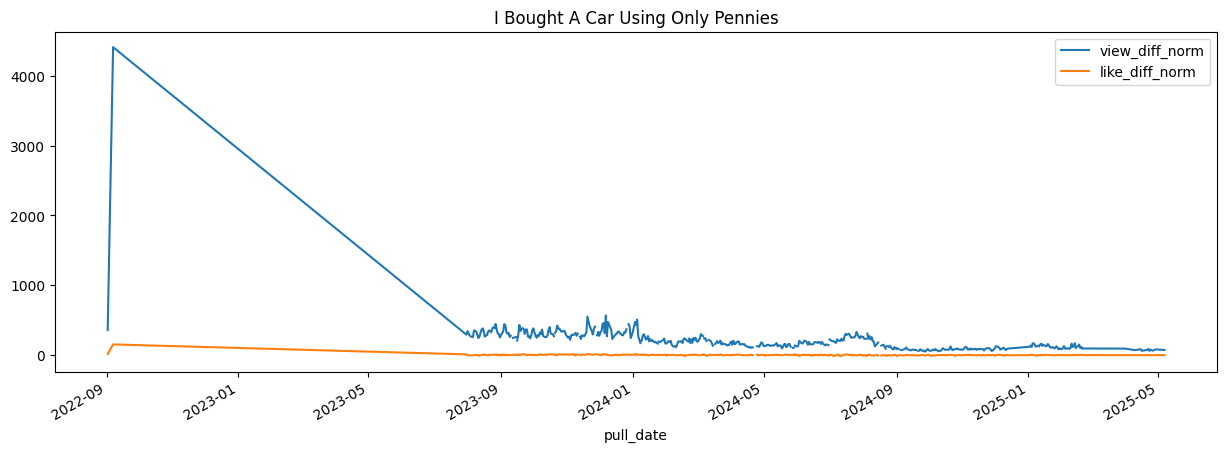

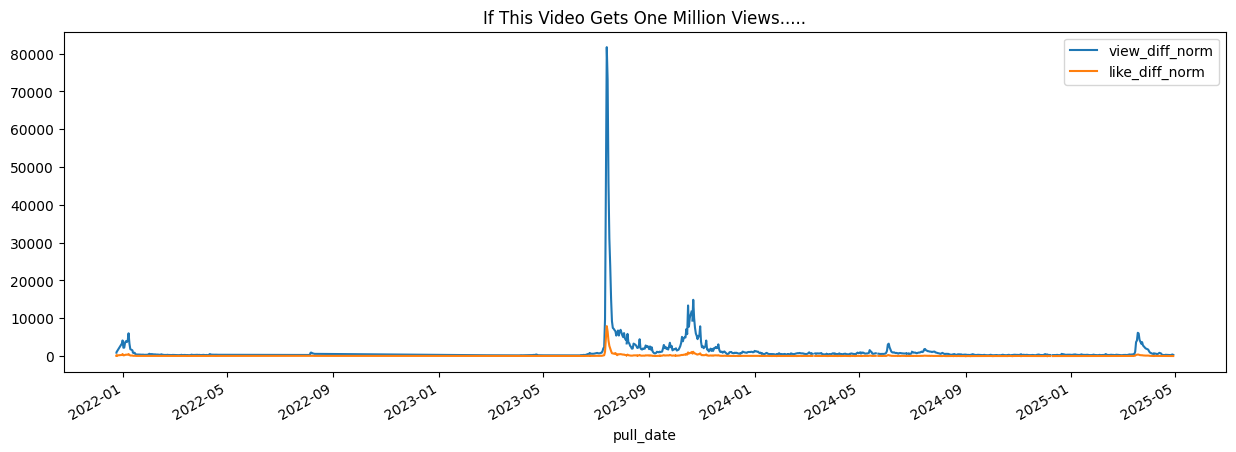

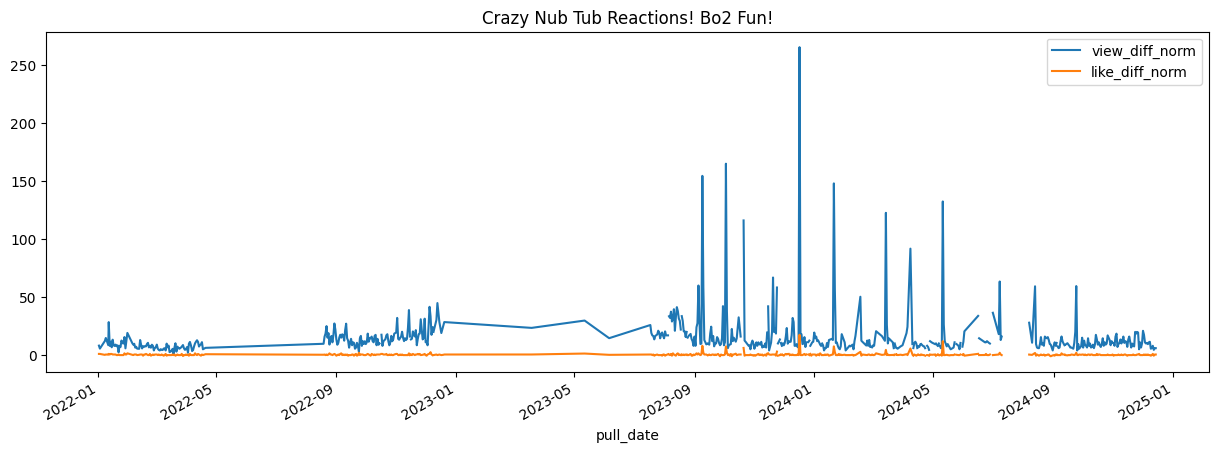

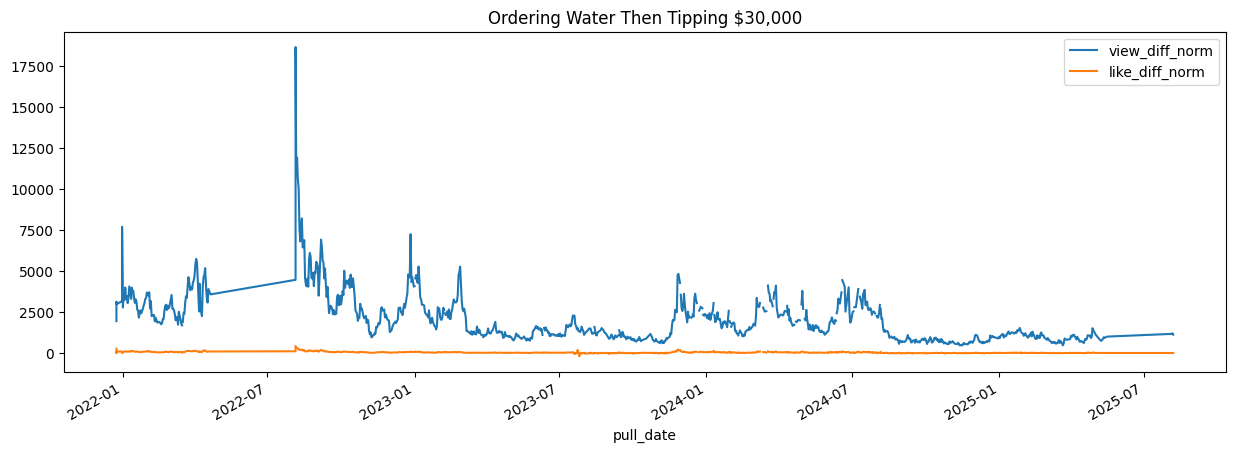

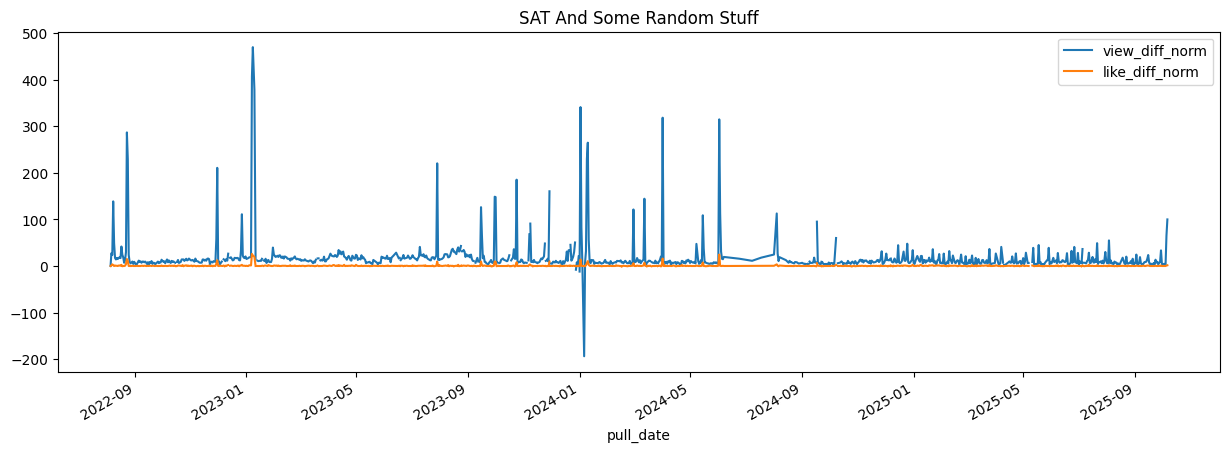

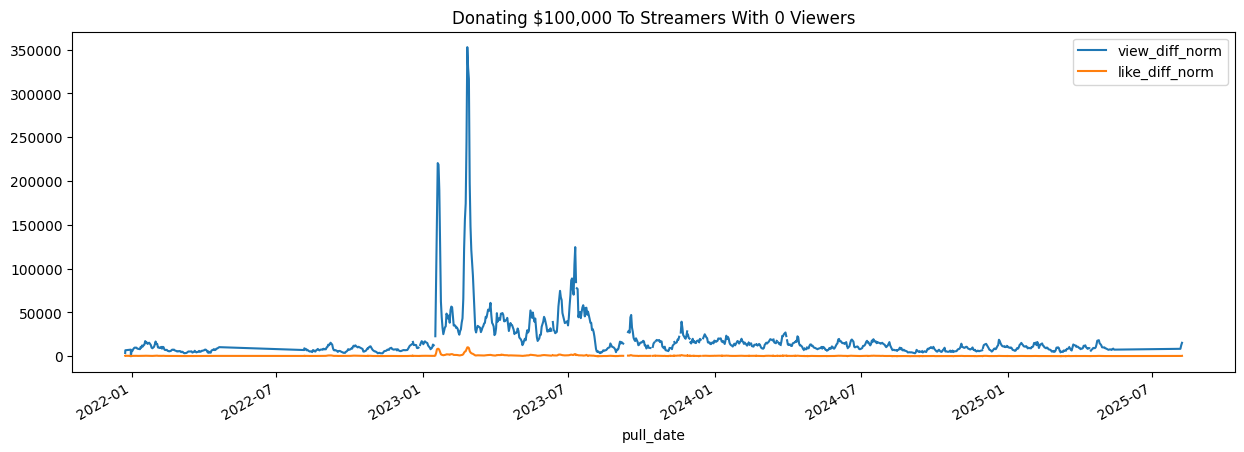

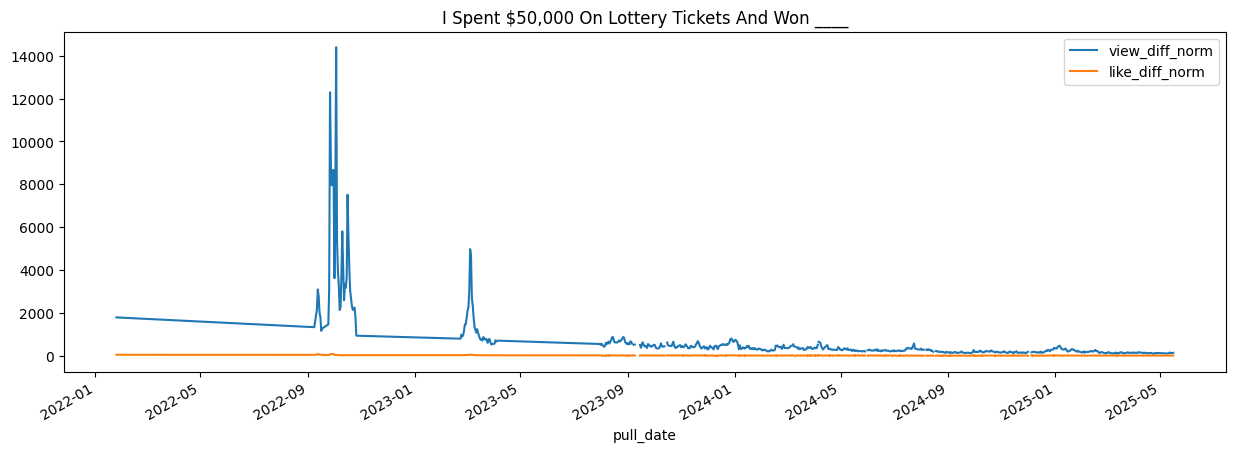

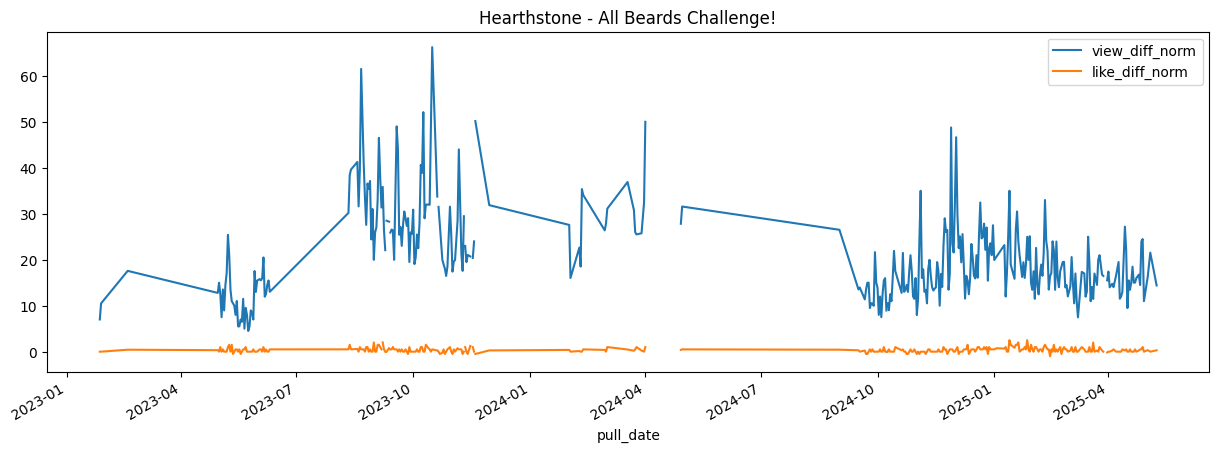

In [60]:
random_vids = df['id'].sample(10, random_state=529).values

for v in random_vids:
    title = df.query('id == @v')['title'].values[0]
    df.query('id == @v').sort_values('pull_date') \
            .set_index('pull_date')[['view_diff_norm','like_diff_norm']].plot(figsize=(15, 5),
                                                       title=title)

# Look at videos with crazy ratios

In [64]:
df['like_ratio_norm'] = df['like_diff_norm'] / df['view_diff_norm']

In [82]:
top_10 = df.query('like_ratio_norm <= 1') \
        .query('view_diff_norm != 0') \
        .groupby('title')['like_ratio_norm'] \
        .max().sort_values(ascending=False)

In [83]:
top_10

title
Knives In Video Games Cost More Than Real Life????    1.000000
More birds IN MINECRAFT!!                             1.000000
5$ To Advertise Your Youtube Channel???               1.000000
Why Do Youtubers Ask For Likes?                       1.000000
I Gave $500,000 To Random People                      1.000000
                                                        ...   
World&#39;s Biggest YouTubers Fight for $1,000,000   -0.000384
Get Every Boy Scout Badge, Win $10,000               -0.006398
Making Fun Of Youtuber&#39;s Intros.                 -0.013158
Every Challenge I&#39;ve Ever Done                   -0.017544
IF ONLINE ADS WERE REAL                              -0.177040
Name: like_ratio_norm, Length: 956, dtype: float64

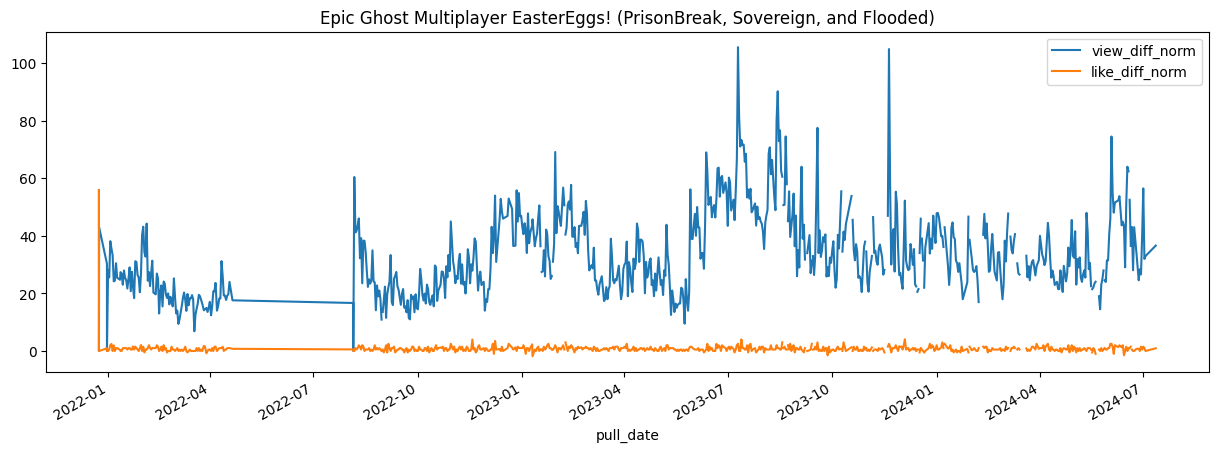

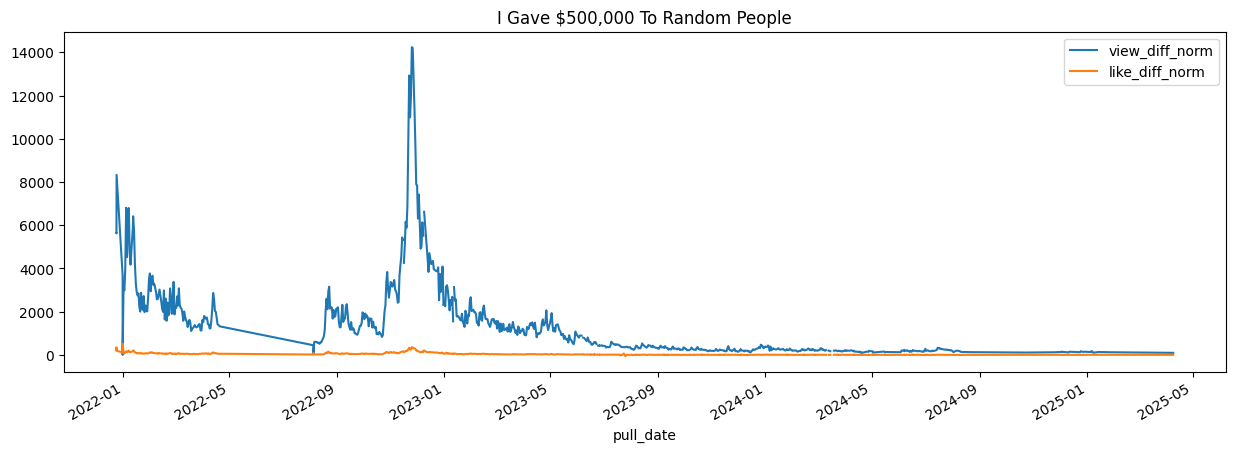

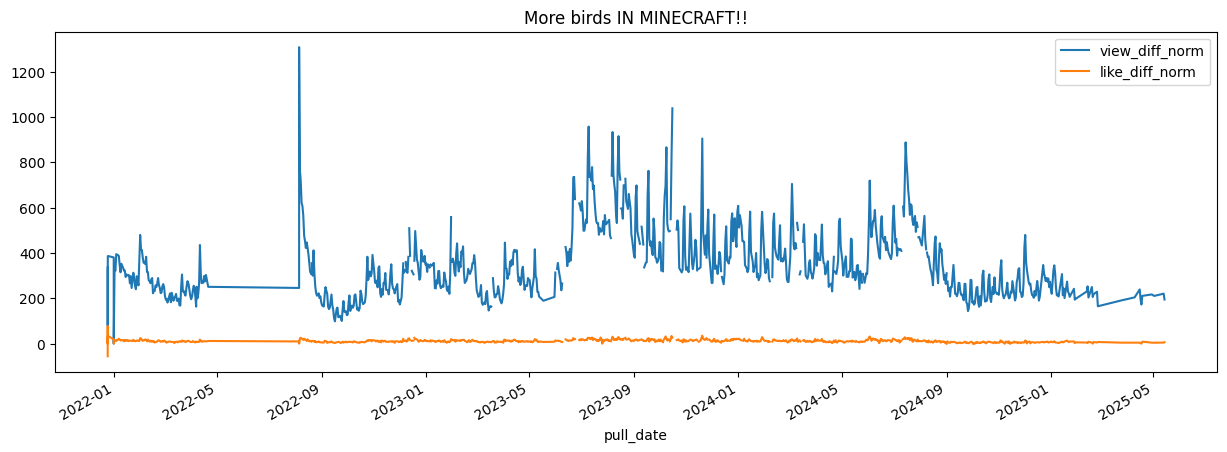

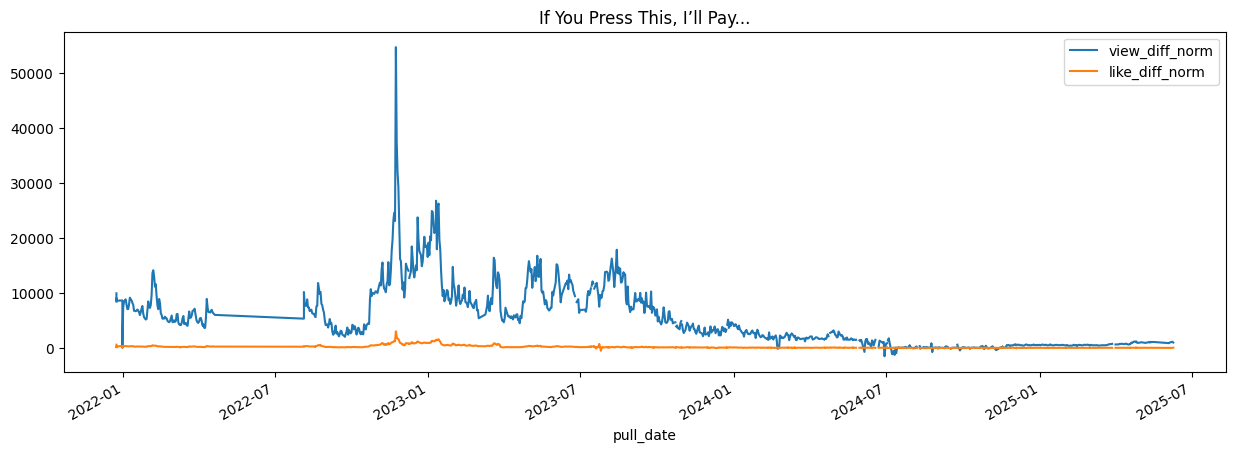

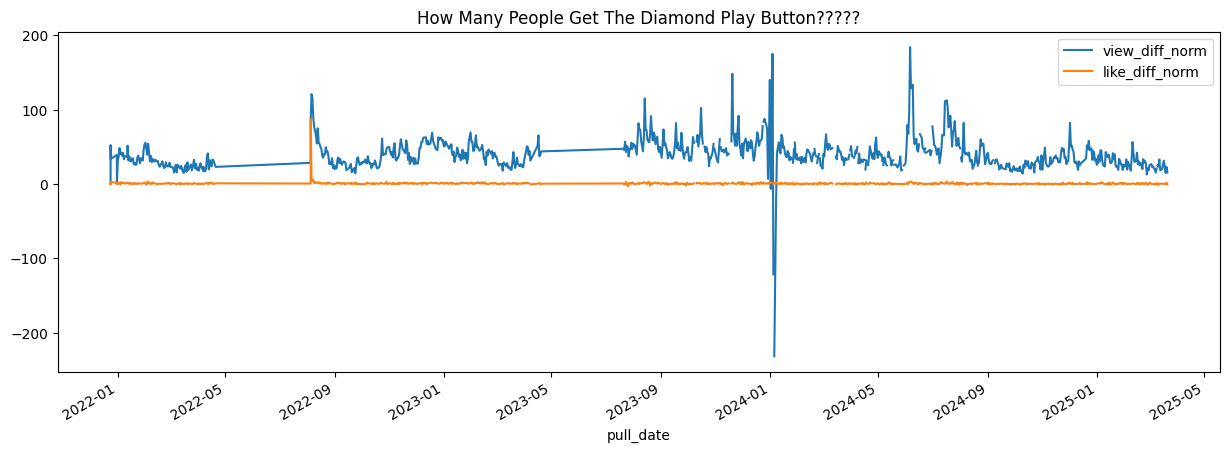

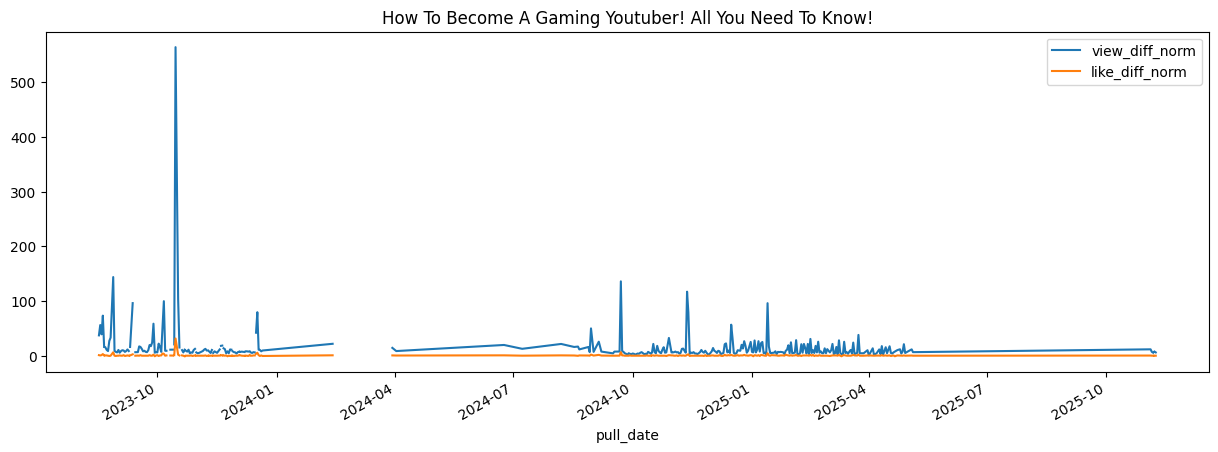

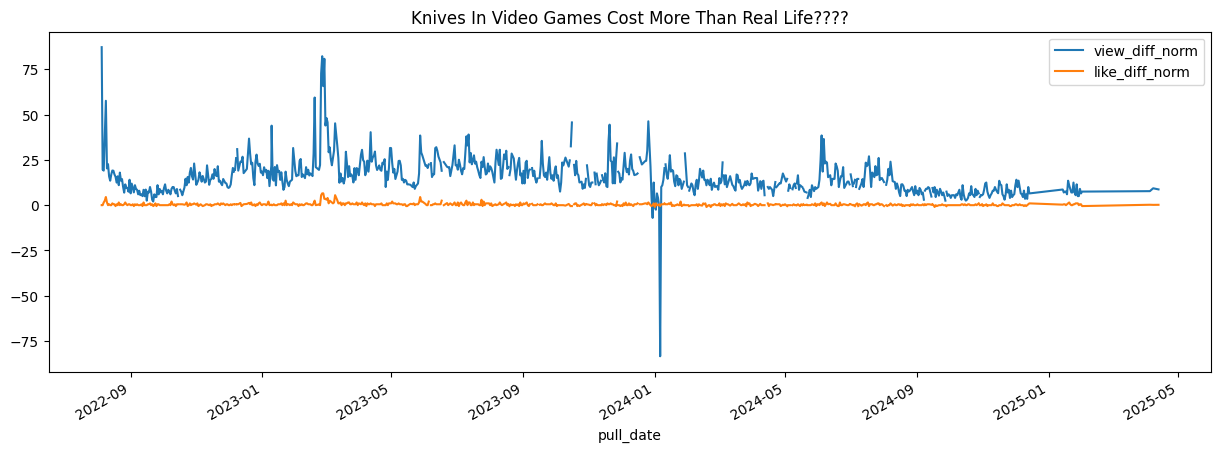

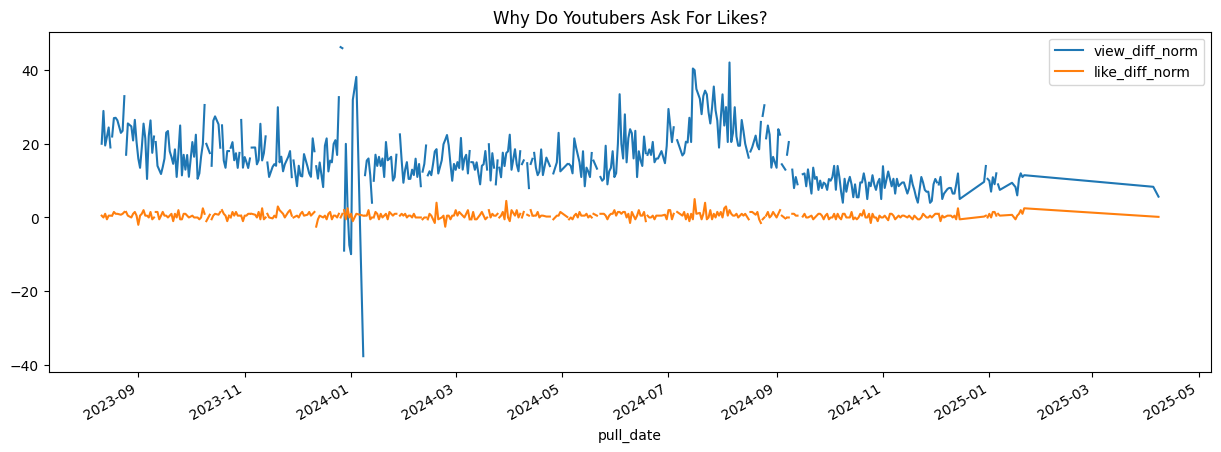

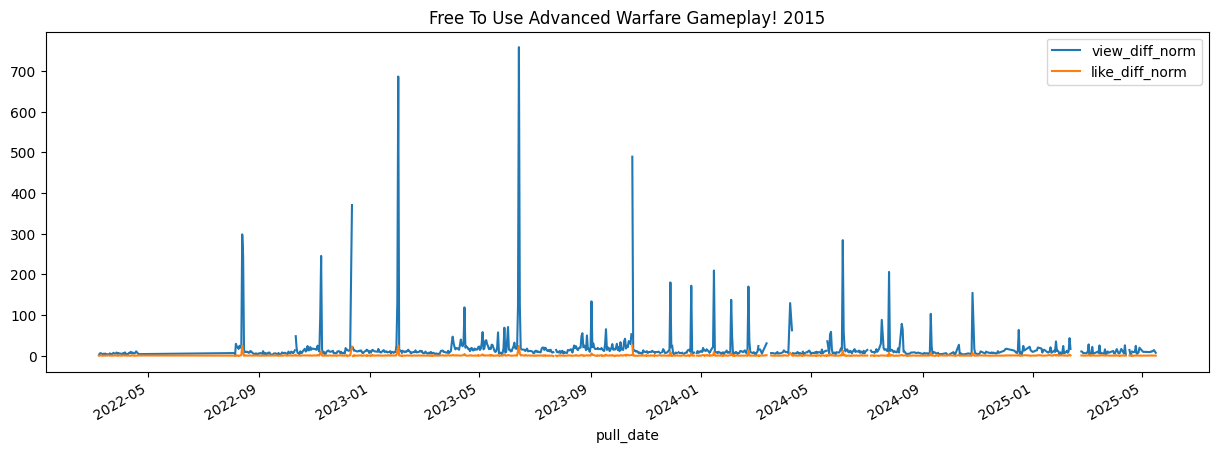

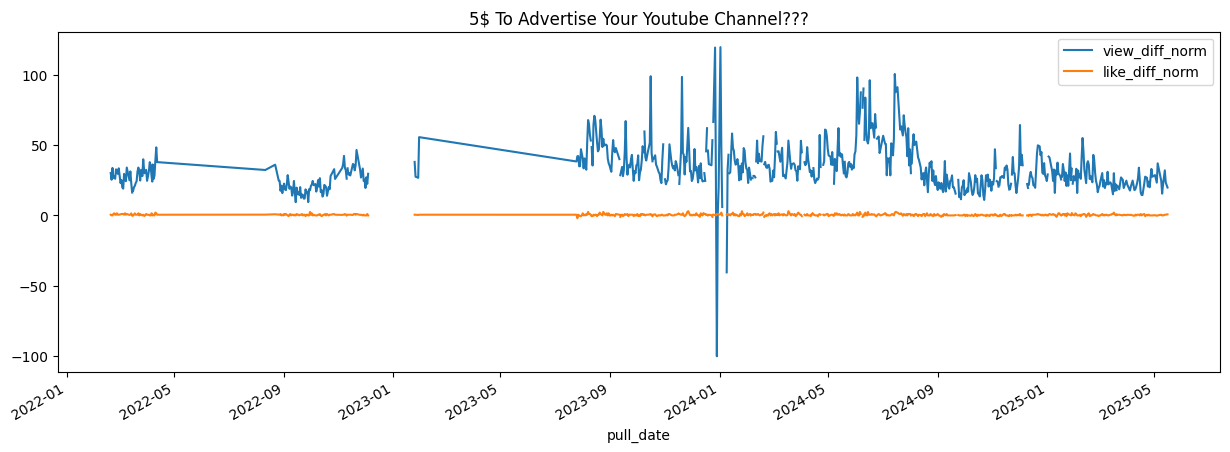

In [79]:
top_10 = df.query('like_ratio_norm <= 1') \
        .query('view_diff_norm != 0') \
        .groupby('id')['like_ratio_norm'] \
        .max().sort_values(ascending=False).index.values[:10]
for v in top_10:
    title = df.query('id == @v')['title'].values[0]
    df.query('id == @v').sort_values('pull_date') \
            .set_index('pull_date')[['view_diff_norm','like_diff_norm']].plot(figsize=(15, 5),
                                                       title=title)

In [110]:
df.query('id == "se50viFJ0AQ"')[['viewCount','likeCount']].corr()

,viewCount,likeCount
viewCount,1.000000,0.992915
likeCount,0.992915,1.000000


In [107]:
pd.set_option('display.max_columns', 50) 
df

,id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.url,thumbnails.default.width,thumbnails.default.height,thumbnails.medium.url,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.url,thumbnails.high.width,thumbnails.high.height,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date
0,ooAwCOP67GQ,Do Pawnshops Scam You?,NaN,2023-06-03 16:59:57+00:00,youtube#video,33,430102763,16483505.0,25590.0,https://i.ytimg.com/vi/ooAwCOP67GQ/default.jpg,120.0,90.0,https://i.ytimg.com/vi/ooAwCOP67GQ/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/ooAwCOP67GQ/hqdefault.jpg,480.0,360.0,PT33S,2d,['https://en.wikipedia.org/wiki/Entertainment'...,en,Do Pawnshops Scam You?,NaN,NaN,2026-01-14 00:04:06.683818+00:00
1,nAiKLoCP-kU,"Reach the Money, Win $10,000",NaN,2025-02-14 18:15:00+00:00,youtube#video,25,498127497,7727492.0,9793.0,https://i.ytimg.com/vi/nAiKLoCP-kU/default.jpg,120.0,90.0,https://i.ytimg.com/vi/nAiKLoCP-kU/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/nAiKLoCP-kU/hqdefault.jpg,480.0,360.0,PT25S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,en,"Reach the Money, Win $10,000",NaN,NaN,2026-01-14 00:04:06.683818+00:00
2,8bTQMDM4qvY,"Spot The Fake Animal For $10,000",NaN,2024-07-19 16:00:00+00:00,youtube#video,40,618427757,17127298.0,29060.0,https://i.ytimg.com/vi/8bTQMDM4qvY/default.jpg,120.0,90.0,https://i.ytimg.com/vi/8bTQMDM4qvY/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/8bTQMDM4qvY/hqdefault.jpg,480.0,360.0,PT40S,2d,['https://en.wikipedia.org/wiki/Entertainment'],en,"Spot The Fake Animal For $10,000",NaN,NaN,2026-01-14 00:04:06.683818+00:00
3,V6In4tmd-w8,"$1 vs $25,000 VFX",Huge thanks to every VFX artist that made this...,2025-06-19 17:00:41+00:00,youtube#video,23,101231484,2422047.0,13261.0,https://i.ytimg.com/vi/V6In4tmd-w8/default.jpg,120.0,90.0,https://i.ytimg.com/vi/V6In4tmd-w8/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/V6In4tmd-w8/hqdefault.jpg,480.0,360.0,PT23S,2d,['https://en.wikipedia.org/wiki/Video_game_cul...,en,"$1 vs $25,000 VFX",Huge thanks to every VFX artist that made this...,NaN,2026-01-14 00:04:06.683818+00:00
4,8krJy31Diow,Holding Bigger And Bigger Dogs,NaN,2024-09-16 18:00:00+00:00,youtube#video,17,329544189,8082587.0,10421.0,https://i.ytimg.com/vi/8krJy31Diow/default.jpg,120.0,90.0,https://i.ytimg.com/vi/8krJy31Diow/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/8krJy31Diow/hqdefault.jpg,480.0,360.0,PT17S,2d,['https://en.wikipedia.org/wiki/Entertainment'...,en,Holding Bigger And Bigger Dogs,NaN,NaN,2026-01-14 00:04:06.683818+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450057,AIytwdufwW8,MY MESSAGE TO COD YOUTUBERS (Watch till end plz),The beginning of the video is a little off top...,2015-05-29 20:07:48+00:00,youtube#video,292,18606,510.0,117.0,https://i.ytimg.com/vi/AIytwdufwW8/default.jpg,120.0,90.0,https://i.ytimg.com/vi/AIytwdufwW8/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/AIytwdufwW8/hqdefault.jpg,480.0,360.0,PT4M52S,2d,['https://en.wikipedia.org/wiki/Action-adventu...,NaN,NaN,NaN,"['How', 'much', 'money', 'does', 'make', 'blac...",2021-12-24 01:41:03.667334+00:00
450058,RCvnytndd9c,"Last To Leave VR Wins $20,000",YOU WON'T BELIEVE HOW LONG THEY LASTED!!! New ...,2019-06-08 20:00:01+00:00,youtube#video,858,82808860,1910890.0,90174.0,https://i.ytimg.com/vi/RCvnytndd9c/default.jpg,120.0,90.0,https://i.ytimg.com/vi/RCvnytndd9c/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/RCvnytndd9c/hqdefault.jpg,480.0,360.0,PT14M18S,2d,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,NaN,NaN,NaN,NaN,2021-12-24 01:41:03.667334+00:00
450059,zi7tZ-2PhLk,How Much Money Do You Make As An Uber Driver??...,In this video I talk about being an uber drive...,2015-05-31 18:31:25+00:00,youtube#video,304,18834,372.0,59.0,https://i.ytimg.co

<Axes: ylabel='Frequency'>

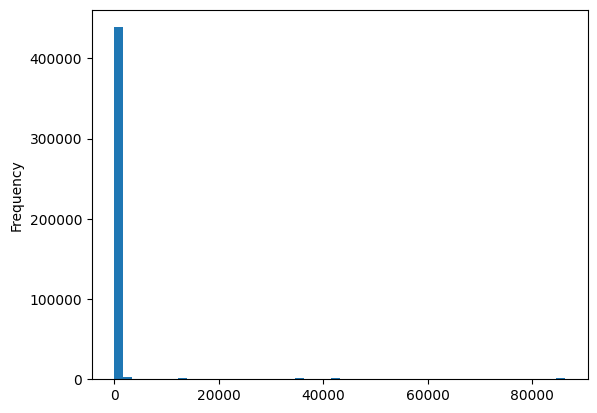

In [93]:
df['duration_seconds'].plot(kind='hist', bins=50)

<Axes: ylabel='Frequency'>

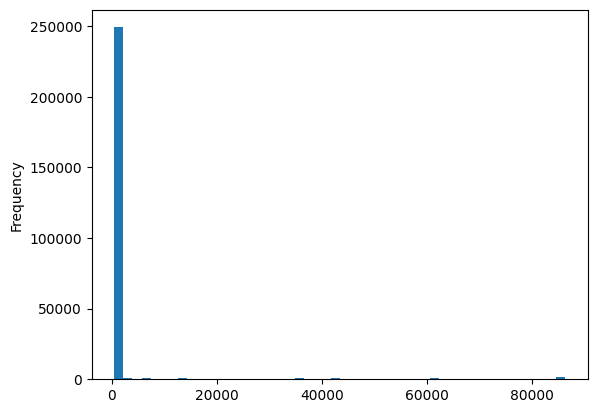

In [95]:
df.query('duration_seconds > 500')['duration_seconds'].plot(kind='hist', bins=50)

In [105]:
df_vid = df.sort_values('pull_date', ascending=False).groupby('id').head(1).reset_index(drop=True)

In [109]:
df_vid['comment_ratio'] = df_vid['commentCount'] / df_vid['viewCount']

In [113]:
df_vid.query('viewCount > 1_000_000').sort_values('comment_ratio', ascending=False)

,id,title,description,publishTime,kind_stats,duration_seconds,viewCount,likeCount,commentCount,thumbnails.default.url,thumbnails.default.width,thumbnails.default.height,thumbnails.medium.url,thumbnails.medium.width,thumbnails.medium.height,thumbnails.high.url,thumbnails.high.width,thumbnails.high.height,contentDetails.duration,contentDetails.dimension,topicDetails.topicCategories,snippet.defaultLanguage,localizations.en.title,localizations.en.description,snippet.tags,pull_date,time_since_last_pull,view_diff,like_diff,comment_diff,like_of_view_ratio,like_to_view_ratio,view_diff_norm,like_diff_norm,like_ratio_norm,comment_ratio
820,TRiF8PdrIP8,MrBeast6000&#39;s Channel Trailer,CLICK THIS LINK FOR PIE! - https://twitter.com...,2015-10-08 20:00:00+00:00,youtube#video,115,1601062,125779,13256,https://i.ytimg.com/vi/TRiF8PdrIP8/default.jpg,120.0,90.0,https://i.ytimg.com/vi/TRiF8PdrIP8/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/TRiF8PdrIP8/hqdefault.jpg,480.0,360.0,PT1M55S,2d,None,None,None,None,"['Mr.Beast', 'mr', 'beast']",2024-07-19 00:09:23.657625+00:00,0 days 23:58:29.632152,289.0,5.0,1.0,0.017301,0.017301,1.446513e+02,2.502618,0.017301,0.008280
528,mGIpOtncmSM,"Saying Pewdiepie 100,000 Times",I SAID HIS NAME 100000 TIMES TO STOP TSERIES I...,2018-11-25 21:07:01+00:00,youtube#video,42520,26527541,1694626,167235,https://i.ytimg.com/vi/mGIpOtncmSM/default.jpg,120.0,90.0,https://i.ytimg.com/vi/mGIpOtncmSM/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/mGIpOtncmSM/hqdefault.jpg,480.0,360.0,PT11H48M40S,2d,None,None,None,None,None,2025-05-02 00:10:08.821562+00:00,3 days 00:06:25.265704,1815.0,-70.0,-9.0,-0.038567,-0.038567,3.020510e+02,-11.649351,-0.038567,0.006304
792,5J6-5g2alp8,"100,000 SUBSCRIBERS.EXE",I never thought this many people would care ab...,2016-07-08 20:00:00+00:00,youtube#video,266,1440272,80380,7891,https://i.ytimg.com/vi/5J6-5g2alp8/default.jpg,120.0,90.0,https://i.ytimg.com/vi/5J6-5g2alp8/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/5J6-5g2alp8/hqdefault.jpg,480.0,360.0,PT4M26S,2d,['https://en.wikipedia.org/wiki/Video_game_cul...,None,None,None,"['100000 subscribers', '100k subs', 'one hundr...",2024-08-27 00:08:15.885955+00:00,19 days 00:00:05.909772,7122.0,156.0,-166.0,0.021904,0.021904,1.874204e+02,4.105248,0.021904,0.005479
559,v1ELS84GQu8,If This Video Gets One Million Views.....,Be a dear and share this with your friends bec...,2013-09-07 02:28:05+00:00,youtube#video,46,13155416,1173452,71958,https://i.ytimg.com/vi/v1ELS84GQu8/default.jpg,120.0,90.0,https://i.ytimg.com/vi/v1ELS84GQu8/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/v1ELS84GQu8/hqdefault.jpg,480.0,360.0,PT46S,2d,None,None,None,None,None,2025-04-29 00:03:43.555858+00:00,1 days 00:00:34.404358,579.0,-18.0,-1.0,-0.031088,-0.031088,2.893848e+02,-8.996418,-0.031088,0.005470
691,fG1N5kzeAhM,Dear Future Me (Scheduled Uploaded 6 Months Ago),"Dear future me, please do not be dead. Btw I a...",2016-04-04 19:30:01+00:00,youtube#video,145,2359615,134610,12523,https://i.ytimg.com/vi/fG1N5kzeAhM/default.jpg,120.0,90.0,https://i.ytimg.com/vi/fG1N5kzeAhM/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/fG1N5kzeAhM/hqdefault.jpg,480.0,360.0,PT2M25S,2d,None,None,None,None,"['Mr.Beast', 'mr', 'beast']",2025-02-13 00:02:01.489061+00:00,0 days 23:59:28.775447,370.0,9.0,0.0,0.024324,0.024324,1.850669e+02,4.501627,0.024324,0.005307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,k194wHZHjB0,Most Expensive Hand Model Holds Feastables,None,2024-02-24 18:00:09+00:00,youtube#video,22,430388949,10863360,8204,https://i.ytimg.com/vi/k194wHZHjB0/default.jpg,120.0,90.0,https://i.ytimg.com/vi/k194wHZHjB0/mqdefault.jpg,320.0,180.0,https://i.ytimg.com/vi/k194wHZHjB0/hqdefault.jpg,480.0,360.0,PT22S,2d,"['https://en.wikipedia.org/wiki/Hobby', 'https...",None,None,None,None,2025-06-08 00:07:05.311499+00:00,1 days 00:05:18.074506,973023.0,6950.0,7.0,0.007143,0.007143,